In [1]:
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio, display
import pandas as pd

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sabermalek/pcvcspeech")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pcvcspeech' dataset.
Path to dataset files: /kaggle/input/pcvcspeech


In [3]:
DATASET_PATH = path
files = sorted([f for f in os.listdir(DATASET_PATH) if f.endswith(".mat")])
files

['S0001.mat',
 'S0001_2.mat',
 'S0002.mat',
 'S0003.mat',
 'S0004.mat',
 'S0005.mat',
 'S0006.mat',
 'S0007.mat',
 'S0008.mat',
 'S0009.mat',
 'S0010.mat',
 'S0011.mat',
 'S0012.mat']

In [4]:
mat = scipy.io.loadmat(os.path.join(DATASET_PATH, "S0001.mat"))
x = mat["x"]

print("Matrix shape:", x.shape)
print("Sampling rate:", 48000)

Matrix shape: (1, 23, 6, 30000)
Sampling rate: 48000


In [5]:
fs = 48000
durations = []
max_vals = []
mean_vals = []

for file in files:
    mat = scipy.io.loadmat(os.path.join(DATASET_PATH, file))
    x = mat["x"]  # shape: (1, 23, 6, 30000)

    for c in range(x.shape[1]):        # consonants
        for v in range(x.shape[2]):    # vowels
            sig = x[0, c, v, :]         # 30000 samples

            durations.append(len(sig) / fs)
            max_vals.append(np.max(np.abs(sig)))
            mean_vals.append(np.mean(np.abs(sig)))

print(f"Average duration: {np.mean(durations):.2f} s")
print(f"Min duration: {np.min(durations):.2f} s")
print(f"Max duration: {np.max(durations):.2f} s")

Average duration: 0.62 s
Min duration: 0.62 s
Max duration: 0.62 s


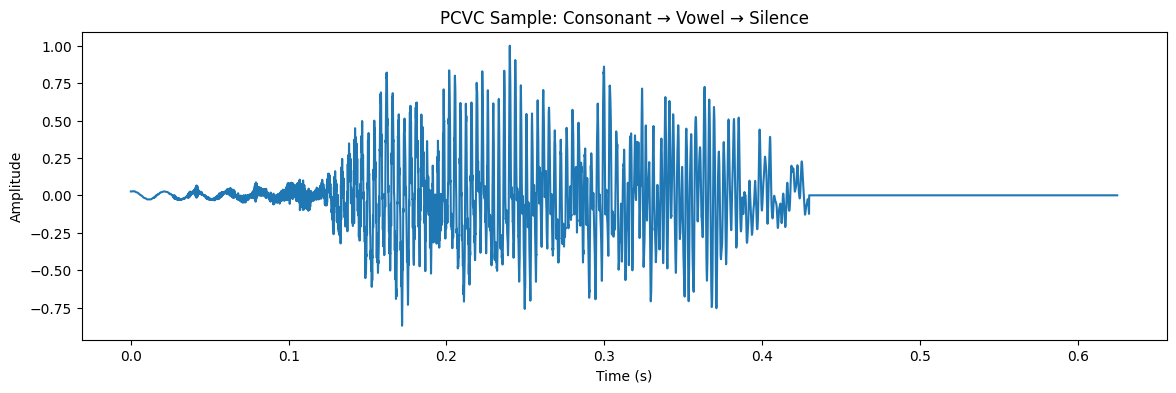

In [6]:
c_idx = 5   # any consonant
v_idx = 2   # any vowel

signal = x[0, c_idx, v_idx, :]
time = np.arange(len(signal)) / fs

plt.figure(figsize=(14,4))
plt.plot(time, signal)
plt.title("PCVC Sample: Consonant → Vowel → Silence")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

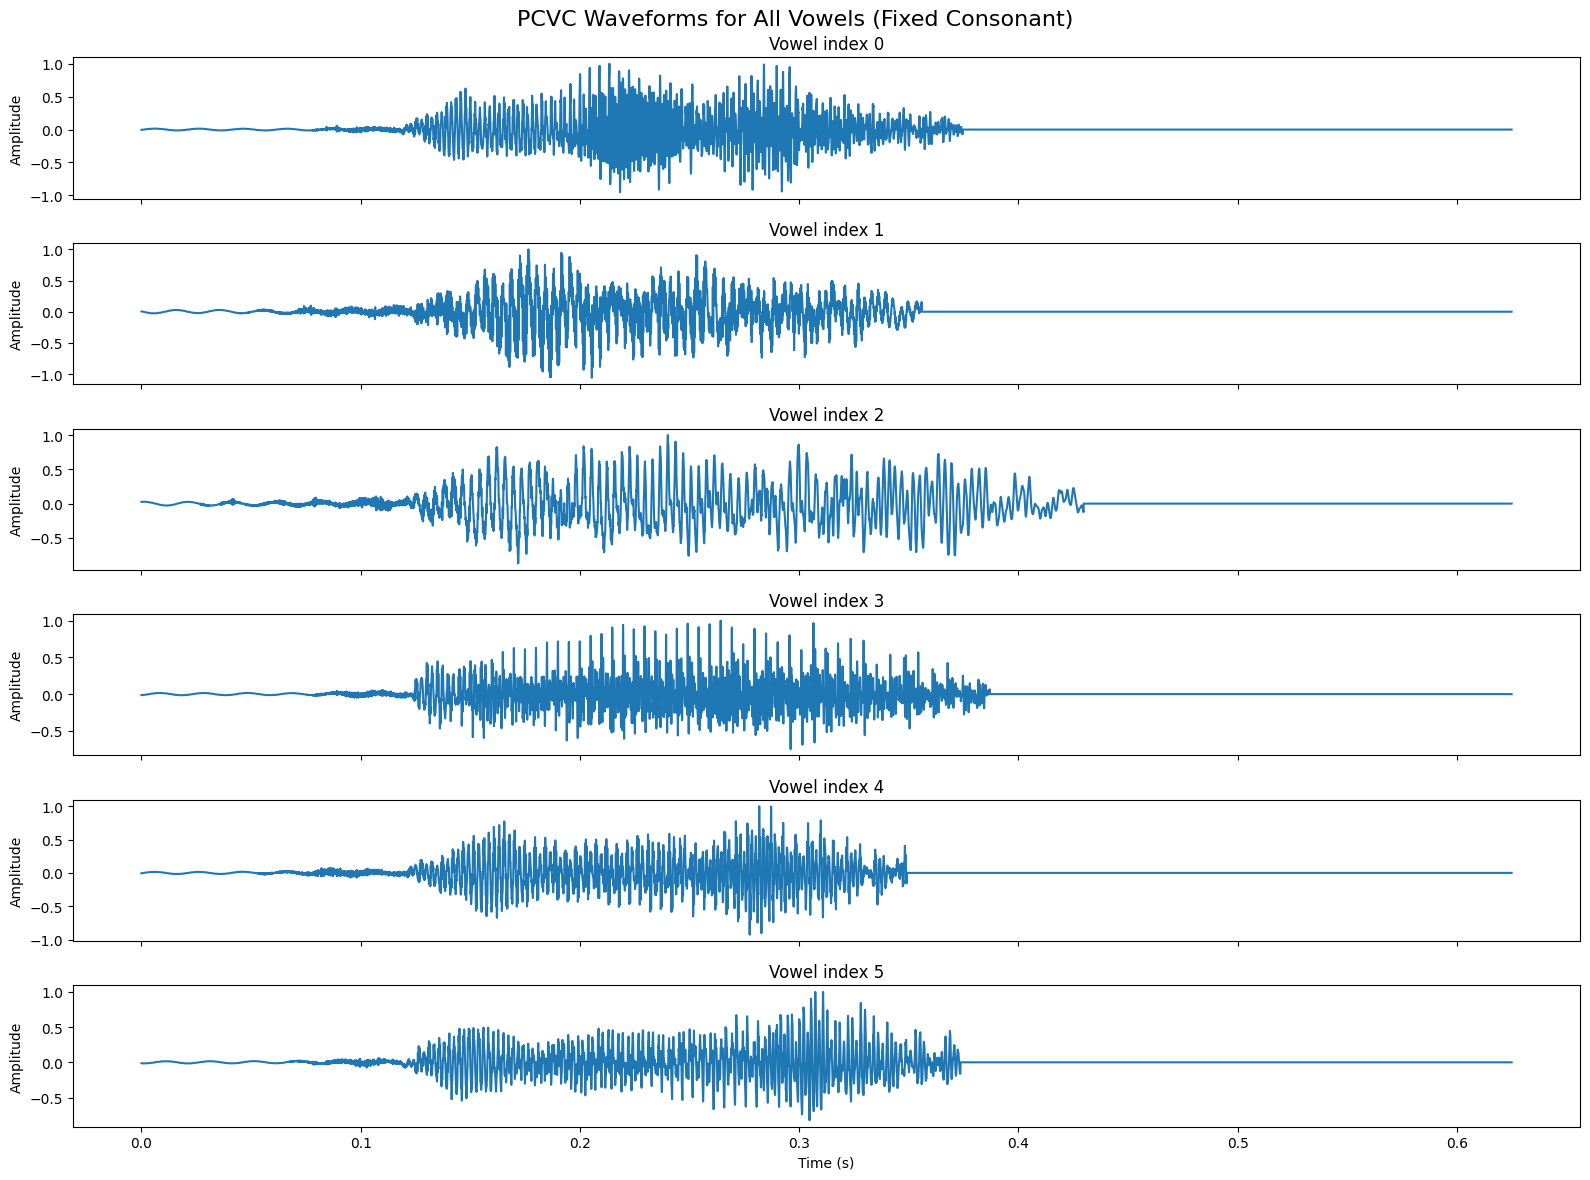

In [7]:
c_idx = 5          # fix one consonant
fs = 48000

fig, axes = plt.subplots(6, 1, figsize=(16, 12), sharex=True)

for v_idx in range(6):
    signal = x[0, c_idx, v_idx, :]
    time = np.arange(len(signal)) / fs

    axes[v_idx].plot(time, signal)
    axes[v_idx].set_title(f"Vowel index {v_idx}")
    axes[v_idx].set_ylabel("Amplitude")

axes[-1].set_xlabel("Time (s)")
plt.suptitle("PCVC Waveforms for All Vowels (Fixed Consonant)", fontsize=16)
plt.tight_layout()
plt.show()

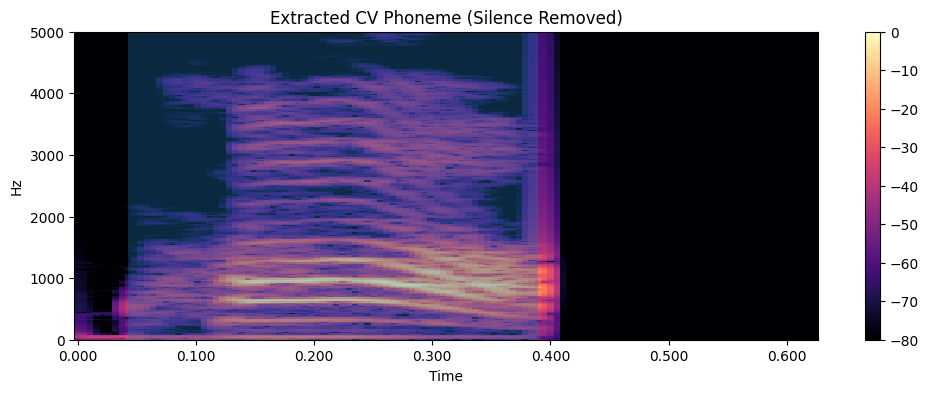

Original:


Extracted full phoneme (CV):


Phoneme duration (s): 0.3436875


In [8]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import scipy.io, os

# -----------------------------
# PARAMETERS
# -----------------------------
fs = 48000
n_fft = 2048
hop_length = 256
silence_ratio = 0.02   # PCVC silence threshold (safe)

# -----------------------------
# LOAD
# -----------------------------
mat = scipy.io.loadmat(os.path.join(DATASET_PATH, "S0001.mat"))
x = mat["x"]

signal = x[0, 0, 0].astype(np.float32)
signal /= np.max(np.abs(signal) + 1e-9)

# -----------------------------
# REMOVE SILENCE (FULL PHONEME)
# -----------------------------
thr = silence_ratio * np.max(np.abs(signal))
mask = np.abs(signal) > thr
idx = np.where(mask)[0]

if len(idx) == 0:
    raise RuntimeError("No speech detected")

start_s, end_s = idx[0], idx[-1]
phoneme = signal[start_s:end_s]
phoneme /= np.max(np.abs(phoneme) + 1e-9)

# -----------------------------
# STFT (VISUALIZATION ONLY)
# -----------------------------
S = np.abs(librosa.stft(signal, n_fft=n_fft, hop_length=hop_length))
times = librosa.frames_to_time(np.arange(S.shape[1]), sr=fs, hop_length=hop_length)

start_f = start_s // hop_length
end_f   = end_s   // hop_length

# -----------------------------
# VISUALIZATION
# -----------------------------
plt.figure(figsize=(12,4))
librosa.display.specshow(
    librosa.amplitude_to_db(S, ref=np.max),
    sr=fs,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz"
)
plt.axvspan(times[start_f], times[end_f], alpha=0.35)
plt.ylim(0, 5000)
plt.title("Extracted CV Phoneme (Silence Removed)")
plt.colorbar()
plt.show()

# -----------------------------
# AUDIO
# -----------------------------
print("Original:")
display(Audio(signal, rate=fs))

print("Extracted full phoneme (CV):")
display(Audio(phoneme, rate=fs))

print("Phoneme duration (s):", len(phoneme)/fs)

In [13]:
import os
import numpy as np
import scipy.io
import librosa
from sklearn.model_selection import train_test_split

FS = 16000
TARGET_DUR = 0.6      # seconds (PCVC average)
SILENCE_RATIO = 0.02  # silence threshold

def remove_silence(signal, ratio=SILENCE_RATIO):
    thr = ratio * np.max(np.abs(signal))
    mask = np.abs(signal) > thr
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return None
    return signal[idx[0]:idx[-1]+1]

def normalize_length(x, sr=FS, dur=TARGET_DUR):
    target_len = int(sr * dur)
    if len(x) > target_len:
        return x[:target_len]
    return np.pad(x, (0, target_len - len(x)))

def normalize_audio(x):
    return x / (np.max(np.abs(x)) + 1e-9)

X = []
y = []
speakers = []

files = sorted([f for f in os.listdir(DATASET_PATH) if f.endswith(".mat")])

for file in files:
    speaker_id = file.replace(".mat", "")
    mat = scipy.io.loadmat(os.path.join(DATASET_PATH, file))
    x = mat["x"]  # (1, 23, 6, 30000)

    for c in range(23):
        for v in range(6):
            sig = x[0, c, v].astype(np.float32)
            sig = normalize_audio(sig)

            sig = remove_silence(sig)
            if sig is None:
                continue

            sig = normalize_length(sig)
            sig = normalize_audio(sig)

            X.append(sig)
            y.append(v)              # vowel label ONLY
            speakers.append(speaker_id)

In [14]:
X = np.stack(X)
y = np.array(y)
speakers = np.array(speakers)

print("Total samples:", len(X))

# -----------------------------
# ORDERED SPEAKER SPLIT
# -----------------------------
unique_speakers = np.unique(speakers)
unique_speakers = np.sort(unique_speakers)

split_ratio = 0.75
num_train = int(len(unique_speakers) * split_ratio)

train_spk = unique_speakers[:num_train]
test_spk  = unique_speakers[num_train:]

# -----------------------------
# APPLY MASKS
# -----------------------------
train_mask = np.isin(speakers, train_spk)
test_mask  = np.isin(speakers, test_spk)

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# -----------------------------
# VERIFY
# -----------------------------
print("Train speakers:", train_spk)
print("Test speakers :", test_spk)
print("Speaker overlap:", set(train_spk) & set(test_spk))
print("Train samples :", len(X_train))
print("Test samples  :", len(X_test))

Total samples: 1794
Train speakers: ['S0001' 'S0001_2' 'S0002' 'S0003' 'S0004' 'S0005' 'S0006' 'S0007' 'S0008']
Test speakers : ['S0009' 'S0010' 'S0011' 'S0012']
Speaker overlap: set()
Train samples : 1242
Test samples  : 552


In [15]:
def normalize_audio(x, eps=1e-9):
    return x / (np.max(np.abs(x)) + eps)

X_train = np.array([normalize_audio(x) for x in X_train])
X_test  = np.array([normalize_audio(x) for x in X_test])

Device: cuda


/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(



Extracting wav2vec2 TRAIN features


100%|██████████| 1242/1242 [00:28<00:00, 43.86it/s]



Extracting wav2vec2 TEST features


100%|██████████| 552/552 [00:16<00:00, 33.73it/s]


Feature shape: (552, 768)

Overall Accuracy: 0.5706521739130435

Classification Report:
              precision    recall  f1-score   support

           0     0.5957    0.6087    0.6022        92
           1     0.5424    0.6957    0.6095        92
           2     0.5000    0.5870    0.5400        92
           3     0.6186    0.6522    0.6349        92
           4     0.6338    0.4891    0.5521        92
           5     0.5625    0.3913    0.4615        92

    accuracy                         0.5707       552
   macro avg     0.5755    0.5707    0.5667       552
weighted avg     0.5755    0.5707    0.5667       552

Macro Precision: 0.5755
Macro Recall   : 0.5707
Macro F1       : 0.5667


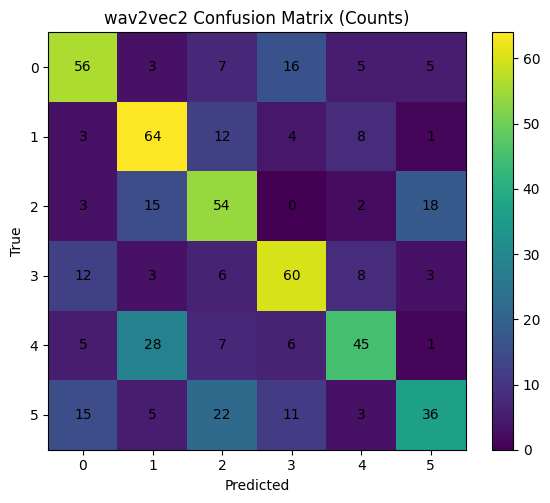

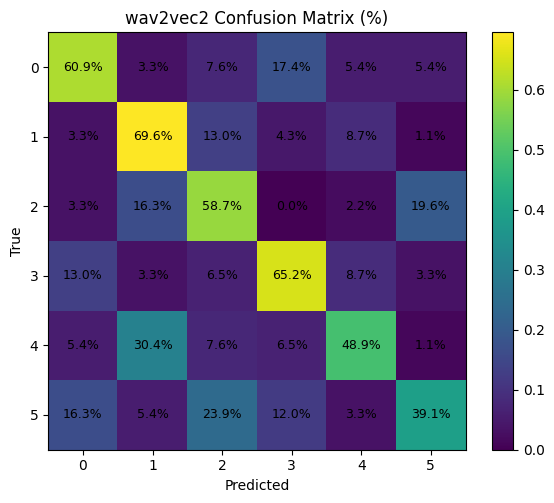


Per-vowel accuracy:
Class 0: 60.87%
Class 1: 69.57%
Class 2: 58.70%
Class 3: 65.22%
Class 4: 48.91%
Class 5: 39.13%


In [44]:
# =========================
# wav2vec2 FEATURE CLASSIFIER
# =========================

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from transformers import Wav2Vec2Processor, Wav2Vec2Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# -----------------------------
# DEVICE
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -----------------------------
# LOAD WAV2VEC2
# -----------------------------
processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base",
    do_normalize=True
)

model = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base"
).to(device)

model.eval()

# -----------------------------
# FEATURE EXTRACTION FUNCTION
# -----------------------------
@torch.no_grad()
def extract_wav2vec2(signal, FS):
    signal = np.asarray(signal, dtype=np.float32)

    inputs = processor(
        signal,
        sampling_rate=FS,
        return_tensors="pt",
        padding=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)

    # Mean pooling over time
    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding.squeeze(0).cpu().numpy()

# -----------------------------
# EXTRACT FEATURES
# -----------------------------
Xtr, Xte = [], []

print("\nExtracting wav2vec2 TRAIN features")
for x in tqdm(X_train):
    Xtr.append(extract_wav2vec2(x, FS))

print("\nExtracting wav2vec2 TEST features")
for x in tqdm(X_test):
    Xte.append(extract_wav2vec2(x, FS))

Xtr = np.stack(Xtr)
X_w2v_test = np.stack(Xte) # Assign to X_w2v_test

print("Feature shape:", X_w2v_test.shape) # Changed to X_w2v_test

# -----------------------------
# CLASSIFIER
# -----------------------------
clf = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    n_jobs=-1,
    solver="lbfgs"
)

clf.fit(Xtr, y_train)

# -----------------------------
# PREDICTION
# -----------------------------
preds_w2v = clf.predict(X_w2v_test) # Use X_w2v_test for prediction

# -----------------------------
# METRICS
# -----------------------------
acc = accuracy_score(y_test, preds_w2v)
print("\nOverall Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, preds_w2v, digits=4))

# Macro metrics (paper-friendly)
p, r, f, _ = precision_recall_fscore_support(
    y_test, preds_w2v, average="macro"
)

print(f"Macro Precision: {p:.4f}")
print(f"Macro Recall   : {r:.4f}")
print(f"Macro F1       : {f:.4f}")

# -----------------------------
# CONFUSION MATRIX (COUNTS)
# -----------------------------
cm = confusion_matrix(y_test, preds_w2v)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("wav2vec2 Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", fontsize=10)

plt.tight_layout()
plt.show()

# -----------------------------
# CONFUSION MATRIX (NORMALIZED %)
# -----------------------------
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
plt.imshow(cm_norm)
plt.title("wav2vec2 Confusion Matrix (%)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i,j]*100:.1f}%",
                 ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# -----------------------------
# PER-VOWEL ACCURACY
# -----------------------------
print("\nPer-vowel accuracy:")
per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc_i in enumerate(per_class_acc):
    print(f"Class {i}: {acc_i*100:.2f}%")

Device: cuda

Extracting HuBERT TRAIN features


100%|██████████| 1242/1242 [00:12<00:00, 96.17it/s] 



Extracting HuBERT TEST features


100%|██████████| 552/552 [00:06<00:00, 90.57it/s]


Feature shape: (1242, 768)

Overall Accuracy: 0.592391304347826

Classification Report:
              precision    recall  f1-score   support

           0     0.6344    0.6413    0.6378        92
           1     0.5833    0.7609    0.6604        92
           2     0.4833    0.6304    0.5472        92
           3     0.6941    0.6413    0.6667        92
           4     0.6456    0.5543    0.5965        92
           5     0.5455    0.3261    0.4082        92

    accuracy                         0.5924       552
   macro avg     0.5977    0.5924    0.5861       552
weighted avg     0.5977    0.5924    0.5861       552

Macro Precision: 0.5977
Macro Recall   : 0.5924
Macro F1       : 0.5861


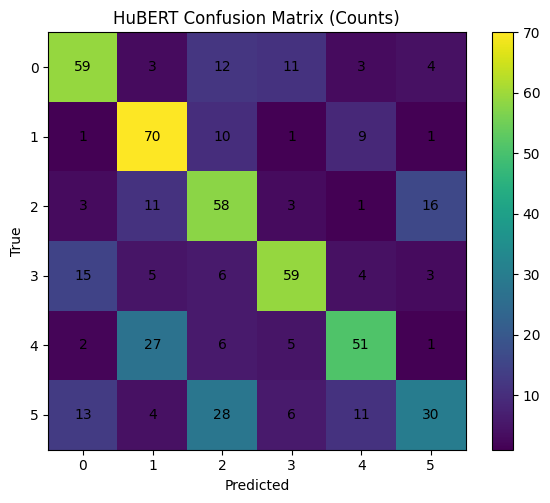

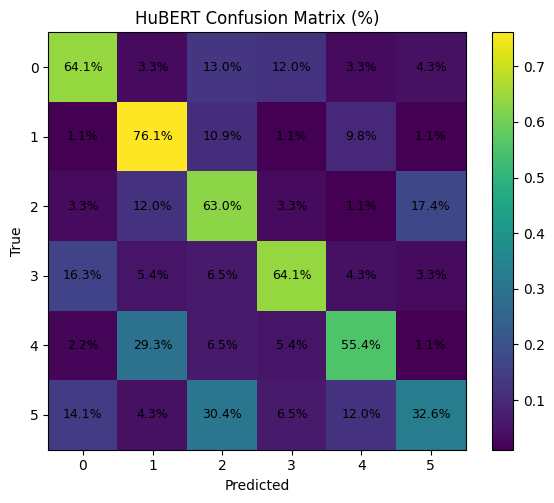


Per-class accuracy:
Class 0: 64.13%
Class 1: 76.09%
Class 2: 63.04%
Class 3: 64.13%
Class 4: 55.43%
Class 5: 32.61%


In [55]:
# =========================
# HuBERT FEATURE CLASSIFIER
# =========================

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from transformers import Wav2Vec2FeatureExtractor, HubertModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# -----------------------------
# DEVICE
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -----------------------------
# LOAD HuBERT
# -----------------------------
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    "facebook/hubert-base-ls960",
    do_normalize=True
)

model = HubertModel.from_pretrained(
    "facebook/hubert-base-ls960"
).to(device)

model.eval()

# -----------------------------
# FEATURE EXTRACTION FUNCTION
# -----------------------------
@torch.no_grad()
def extract_hubert(signal, FS):
    signal = np.asarray(signal, dtype=np.float32)

    inputs = feature_extractor(
        signal,
        sampling_rate=FS,
        return_tensors="pt",
        padding=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)

    # Mean pooling over time
    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding.squeeze(0).cpu().numpy()

# -----------------------------
# EXTRACT FEATURES
# -----------------------------
Xtr, Xte = [], []

print("\nExtracting HuBERT TRAIN features")
for x in tqdm(X_train):
    Xtr.append(extract_hubert(x, FS))

print("\nExtracting HuBERT TEST features")
for x in tqdm(X_test):
    Xte.append(extract_hubert(x, FS))

Xtr = np.stack(Xtr)
X_hubert_test = np.stack(Xte) # Assign to X_hubert_test

print("Feature shape:", Xtr.shape)

# -----------------------------
# CLASSIFIER
# -----------------------------
clf = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    n_jobs=-1,
    solver="lbfgs"
)

clf.fit(Xtr, y_train)

# -----------------------------
# PREDICTION
# -----------------------------
preds_hubert = clf.predict(X_hubert_test) # Use X_hubert_test for prediction

# -----------------------------
# METRICS
# -----------------------------
acc = accuracy_score(y_test, preds_hubert)
print("\nOverall Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, preds_hubert, digits=4))

# Macro metrics (paper-friendly)
p, r, f, _ = precision_recall_fscore_support(
    y_test, preds_hubert, average="macro"
)

print(f"Macro Precision: {p:.4f}")
print(f"Macro Recall   : {r:.4f}")
print(f"Macro F1       : {f:.4f}")

# -----------------------------
# CONFUSION MATRIX (COUNTS)
# -----------------------------
cm = confusion_matrix(y_test, preds_hubert)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("HuBERT Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", fontsize=10)

plt.tight_layout()
plt.show()

# -----------------------------
# CONFUSION MATRIX (NORMALIZED %)
# -----------------------------
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
plt.imshow(cm_norm)
plt.title("HuBERT Confusion Matrix (%)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i,j]*100:.1f}%",
                 ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# -----------------------------
# PER-CLASS ACCURACY
# -----------------------------
print("\nPer-class accuracy:")
per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc_i in enumerate(per_class_acc):
    print(f"Class {i}: {acc_i*100:.2f}%")

Device: cuda

Whisper → extracting TRAIN


100%|██████████| 1242/1242 [02:27<00:00,  8.44it/s]



Whisper → extracting TEST


100%|██████████| 552/552 [01:05<00:00,  8.44it/s]

Feature shape: (1242, 768)



Overall Accuracy: 0.6702898550724637

Classification Report:
              precision    recall  f1-score   support

           0     0.6667    0.6957    0.6809        92
           1     0.5948    0.7500    0.6635        92
           2     0.6019    0.6739    0.6359        92
           3     0.8000    0.7826    0.7912        92
           4     0.6813    0.6739    0.6776        92
           5     0.7321    0.4457    0.5541        92

    accuracy                         0.6703       552
   macro avg     0.6795    0.6703    0.6672       552
weighted avg     0.6795    0.6703    0.6672       552

Macro Precision: 0.6795
Macro Recall   : 0.6703
Macro F1       : 0.6672


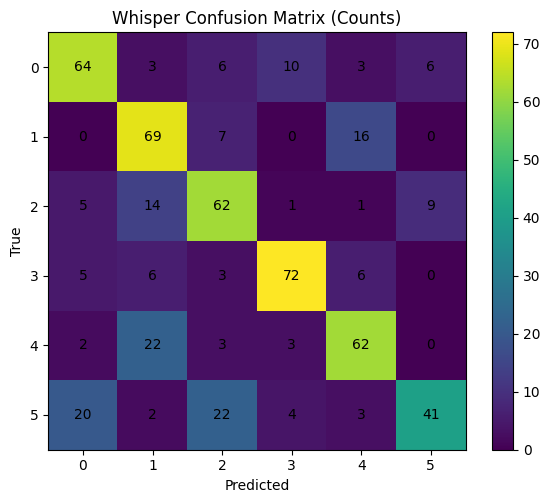

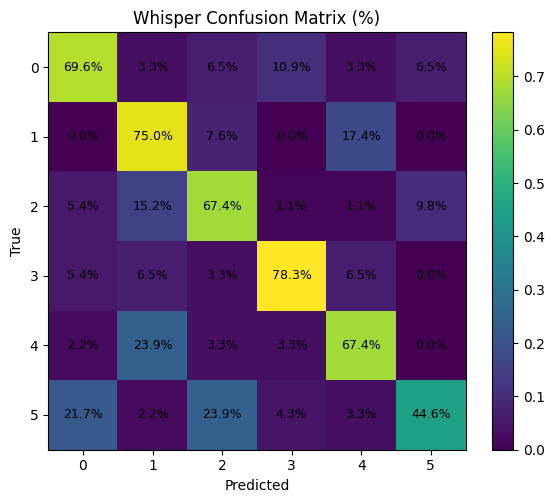


Per-class accuracy:
Class 0: 69.57%
Class 1: 75.00%
Class 2: 67.39%
Class 3: 78.26%
Class 4: 67.39%
Class 5: 44.57%


In [56]:
# =========================
# WHISPER FEATURE CLASSIFIER
# =========================
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from transformers import WhisperProcessor, WhisperModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# -----------------------------
# DEVICE
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -----------------------------
# LOAD WHISPER (ENCODER ONLY)
# -----------------------------
processor = WhisperProcessor.from_pretrained(
    "openai/whisper-small"
)

model = WhisperModel.from_pretrained(
    "openai/whisper-small"
).to(device)

model.eval()

# -----------------------------
# FEATURE EXTRACTION FUNCTION
# -----------------------------
@torch.no_grad()
def extract_whisper(signal, FS):
    signal = np.asarray(signal, dtype=np.float32)

    inputs = processor(
        signal,
        sampling_rate=FS,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Encoder embeddings only
    encoder_outputs = model.encoder(**inputs)

    # Mean pooling over time
    embedding = encoder_outputs.last_hidden_state.mean(dim=1)

    return embedding.squeeze(0).cpu().numpy()

# -----------------------------
# EXTRACT FEATURES
# -----------------------------
Xtr, Xte = [], []

print("\nWhisper → extracting TRAIN")
for x in tqdm(X_train):
    Xtr.append(extract_whisper(x, FS))

print("\nWhisper → extracting TEST")
for x in tqdm(X_test):
    Xte.append(extract_whisper(x, FS))

Xtr = np.stack(Xtr)
X_whisper_test = np.stack(Xte) # Assign to X_whisper_test

print("Feature shape:", Xtr.shape)

# -----------------------------
# CLASSIFIER
# -----------------------------
clf = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    n_jobs=-1,
    solver="lbfgs"
)

clf.fit(Xtr, y_train)

# -----------------------------
# PREDICTION
# -----------------------------
preds_whisper = clf.predict(X_whisper_test) # Use X_whisper_test for prediction

# -----------------------------
# METRICS
# -----------------------------
acc = accuracy_score(y_test, preds_whisper)
print("\nOverall Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, preds_whisper, digits=4))

# Macro metrics
p, r, f, _ = precision_recall_fscore_support(
    y_test, preds_whisper, average="macro"
)

print(f"Macro Precision: {p:.4f}")
print(f"Macro Recall   : {r:.4f}")
print(f"Macro F1       : {f:.4f}")

# -----------------------------
# CONFUSION MATRIX (COUNTS)
# -----------------------------
cm = confusion_matrix(y_test, preds_whisper)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Whisper Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center", fontsize=10
        )

plt.tight_layout()
plt.show()

# -----------------------------
# CONFUSION MATRIX (NORMALIZED %)
# -----------------------------
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
plt.imshow(cm_norm)
plt.title("Whisper Confusion Matrix (%)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i, f"{cm_norm[i, j]*100:.1f}%",
            ha="center", va="center", fontsize=9
        )

plt.tight_layout()
plt.show()

# -----------------------------
# PER-CLASS ACCURACY
# -----------------------------
print("\nPer-class accuracy:")
per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc_i in enumerate(per_class_acc):
    print(f"Class {i}: {acc_i*100:.2f}%")

In [33]:
import numpy as np
from collections import Counter

def count_vowels(y, class_names=None):
    counts = Counter(y)

    print("Total samples per vowel:\n")
    for k in sorted(counts.keys()):
        if class_names:
            print(f"Class {k} ({class_names[k]}): {counts[k]}")
        else:
            print(f"Class {k}: {counts[k]}")

    print("\nTotal samples:", len(y))

In [35]:
count_vowels(y)

Total samples per vowel:

Class 0: 299
Class 1: 299
Class 2: 299
Class 3: 299
Class 4: 299
Class 5: 299

Total samples: 1794


Epoch 1/20: 100%|██████████| 39/39 [00:00<00:00, 131.41it/s]


Epoch 1: Loss=1.6937, Acc=29.39%


Epoch 2/20: 100%|██████████| 39/39 [00:00<00:00, 183.65it/s]


Epoch 2: Loss=1.1793, Acc=56.12%


Epoch 3/20: 100%|██████████| 39/39 [00:00<00:00, 185.88it/s]


...

Epoch 18: Loss=0.3583, Acc=89.21%


Epoch 19/20: 100%|██████████| 39/39 [00:00<00:00, 186.21it/s]


Epoch 19: Loss=0.3375, Acc=89.69%


Epoch 20/20: 100%|██████████| 39/39 [00:00<00:00, 189.35it/s]


Epoch 20: Loss=0.3237, Acc=90.34%


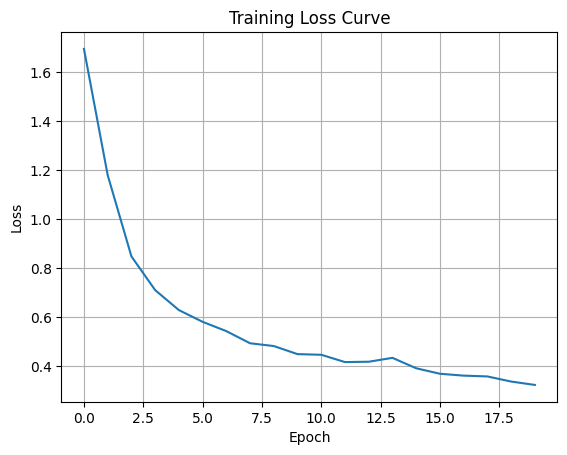

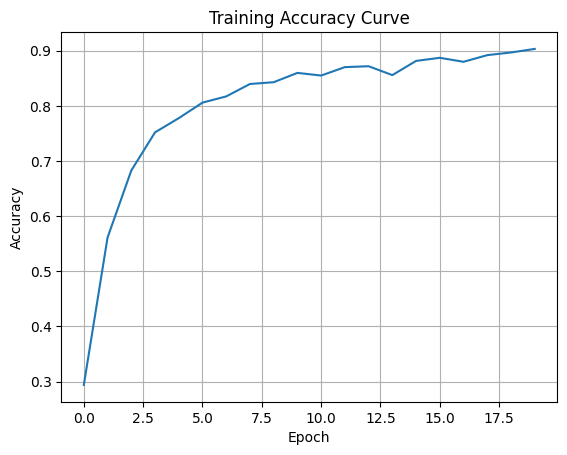


Final Test Accuracy: 0.7572463768115942
              precision    recall  f1-score   support

           0     0.7474    0.7717    0.7594        92
           1     0.7170    0.8261    0.7677        92
           2     0.6471    0.8370    0.7299        92
           3     0.8557    0.9022    0.8783        92
           4     0.8161    0.7717    0.7933        92
           5     0.8333    0.4348    0.5714        92

    accuracy                         0.7572       552
   macro avg     0.7694    0.7572    0.7500       552
weighted avg     0.7694    0.7572    0.7500       552


Per-Class Accuracy:
Class 0: 77.17%
Class 1: 82.61%
Class 2: 83.70%
Class 3: 90.22%
Class 4: 77.17%
Class 5: 43.48%


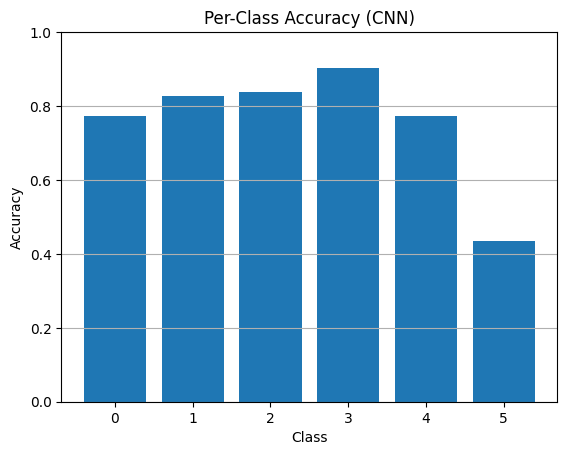

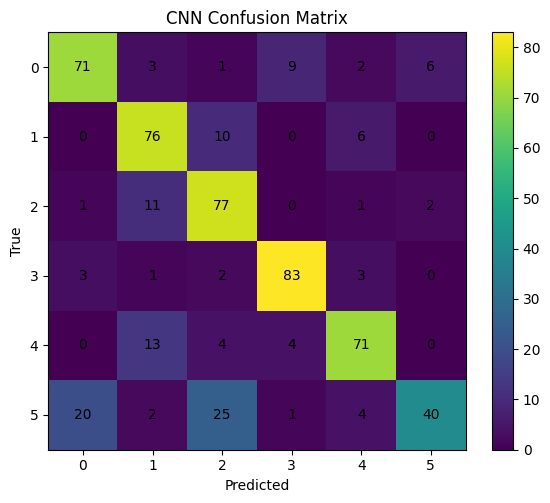

CNN embedding shape for UMAP: (552, 64)


In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Dataset
# -----------------------------
class VowelDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(0), self.y[idx]

# -----------------------------
# CNN Model
# -----------------------------
class CNN1D(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, 9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(16, 32, 7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = x.squeeze(-1)
        return self.fc(x)

# -----------------------------
# DataLoaders
# -----------------------------
batch_size = 32
train_loader = DataLoader(VowelDataset(X_train, y_train),
                          batch_size=batch_size, shuffle=True)
test_loader = DataLoader(VowelDataset(X_test, y_test),
                         batch_size=batch_size, shuffle=False)

# -----------------------------
# Training Setup
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNN1D(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

train_losses = []
train_accs = []

# -----------------------------
# Training Loop
# -----------------------------
for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    running_loss = 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc*100:.2f}%")

# -----------------------------
# Training Curves
# -----------------------------
plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid()
plt.show()

plt.figure()
plt.plot(train_accs)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")
plt.grid()
plt.show()

# -----------------------------
# Evaluation
# -----------------------------
model.eval()
y_true, preds_cnn = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        y_true.extend(yb.cpu().numpy())
        preds_cnn.extend(preds.cpu().numpy())

y_true = np.array(y_true)
preds_cnn = np.array(preds_cnn)

print("\nFinal Test Accuracy:", accuracy_score(y_true, preds_cnn))
print(classification_report(y_true, preds_cnn, digits=4))

# -----------------------------
# Per-Class Accuracy
# -----------------------------
print("\nPer-Class Accuracy:")
class_acc = {}
for c in np.unique(y_true):
    idx = y_true == c
    acc = (preds_cnn[idx] == c).mean()
    class_acc[c] = acc
    print(f"Class {c}: {acc*100:.2f}%")

# Bar plot
plt.figure()
plt.bar([str(k) for k in class_acc.keys()],
        class_acc.values())
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy (CNN)")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

# -----------------------------
# Confusion Matrix (with numbers)
# -----------------------------
cm = confusion_matrix(y_true, preds_cnn)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("CNN Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()

# -----------------------------
# EXTRACT CNN EMBEDDINGS FOR UMAP
# -----------------------------
X_cnn_embed_test = []
model.eval()
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        # Get output from the convolutional layers before the final FC layer
        cnn_output = model.conv(xb)
        # Squeeze the last dimension as in the forward pass
        embeddings = cnn_output.squeeze(-1).cpu().numpy()
        X_cnn_embed_test.append(embeddings)

X_cnn_embed_test = np.vstack(X_cnn_embed_test)
print("CNN embedding shape for UMAP:", X_cnn_embed_test.shape)


In [58]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

def mcnemar_test(y_true, p1, p2, name1, name2):
    c1 = (p1 == y_true)
    c2 = (p2 == y_true)

    table = [
        [np.sum(c1 & c2), np.sum(c1 & ~c2)],
        [np.sum(~c1 & c2), np.sum(~c1 & ~c2)]
    ]

    result = mcnemar(table, exact=False, correction=True)

    print(f"\n{name1} vs {name2}")
    print("Contingency Table:", table)
    print(f"Statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")

    if result.pvalue < 0.05:
        print(" Statistically significant")
    else:
        print(" Not significant")

In [59]:
mcnemar_test(y_test, preds_w2v, preds_whisper, "wav2vec2", "Whisper")
mcnemar_test(y_test, preds_hubert, preds_whisper, "HuBERT", "Whisper")
mcnemar_test(y_test, preds_whisper, preds_cnn, "Whisper", "CNN")
mcnemar_test(y_test, preds_w2v, preds_cnn, "wav2vec2", "CNN")


wav2vec2 vs Whisper
Contingency Table: [[np.int64(256), np.int64(59)], [np.int64(114), np.int64(123)]]
Statistic=16.8555, p-value=0.000040
 Statistically significant

HuBERT vs Whisper
Contingency Table: [[np.int64(276), np.int64(51)], [np.int64(94), np.int64(131)]]
Statistic=12.1655, p-value=0.000487
 Statistically significant

Whisper vs CNN
Contingency Table: [[np.int64(324), np.int64(46)], [np.int64(94), np.int64(88)]]
Statistic=15.7786, p-value=0.000071
 Statistically significant

wav2vec2 vs CNN
Contingency Table: [[np.int64(262), np.int64(53)], [np.int64(156), np.int64(81)]]
Statistic=49.7799, p-value=0.000000
 Statistically significant


In [60]:
def bootstrap_acc(y, p1, p2, name1, name2, n=10000):
    rng = np.random.default_rng(42)
    diffs = []

    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        acc1 = np.mean(p1[idx] == y[idx])
        acc2 = np.mean(p2[idx] == y[idx])
        diffs.append(acc1 - acc2)

    diffs = np.array(diffs)
    lo, hi = np.percentile(diffs, [2.5, 97.5])

    print(f"\n{name1} − {name2}")
    print(f"Mean ΔAcc = {diffs.mean():.4f}")
    print(f"95% CI = [{lo:.4f}, {hi:.4f}]")

In [61]:
bootstrap_acc(y_test, preds_whisper, preds_w2v, "Whisper", "wav2vec2")
bootstrap_acc(y_test, preds_cnn, preds_whisper, "CNN", "Whisper")
bootstrap_acc(y_test, preds_cnn, preds_hubert, "CNN", "HuBERT")


Whisper − wav2vec2
Mean ΔAcc = 0.0995
95% CI = [0.0525, 0.1449]

CNN − Whisper
Mean ΔAcc = 0.0869
95% CI = [0.0471, 0.1268]

CNN − HuBERT
Mean ΔAcc = 0.1650
95% CI = [0.1196, 0.2101]


In [71]:
import umap
import matplotlib.pyplot as plt

def plot_umap(X, y, title):
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )
    Z = reducer.fit_transform(X)

    plt.figure(figsize=(6,5))
    sc = plt.scatter(Z[:,0], Z[:,1], c=y, s=15)
    plt.colorbar(sc)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return Z # Return the UMAP embeddings

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


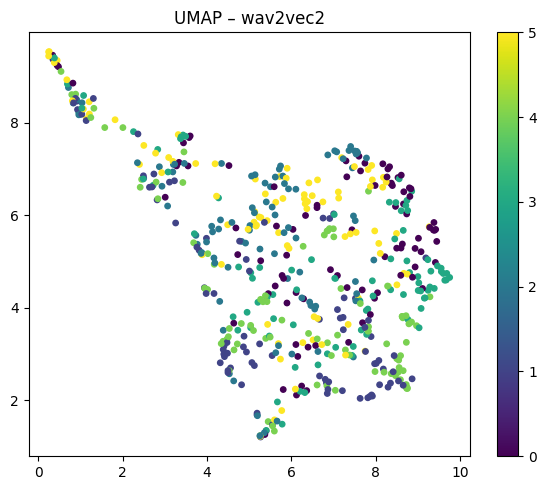

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


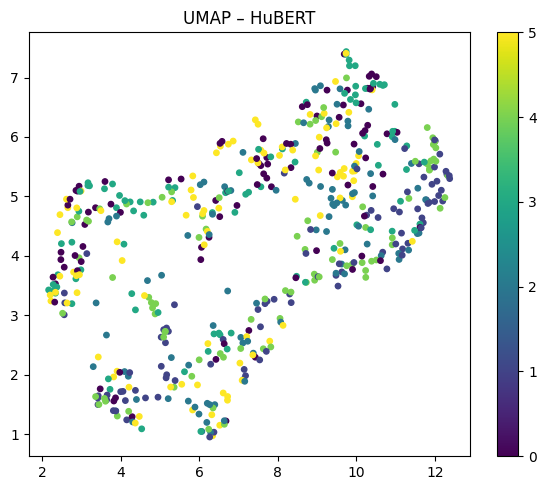

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


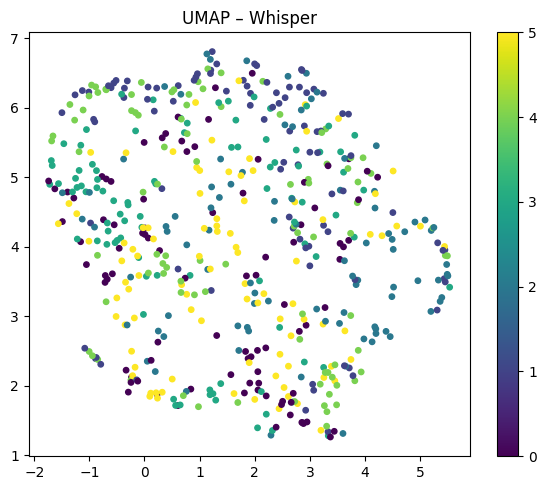

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


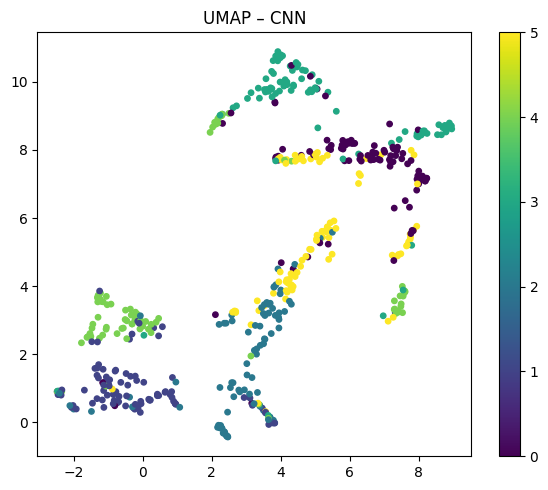

In [72]:
Z_w2v = plot_umap(X_w2v_test, y_test, "UMAP – wav2vec2")
Z_hubert = plot_umap(X_hubert_test, y_test, "UMAP – HuBERT")
Z_whisper = plot_umap(X_whisper_test, y_test, "UMAP – Whisper")
Z_cnn = plot_umap(X_cnn_embed_test, y_test, "UMAP – CNN")

In [76]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

def cluster_separability_metrics(embeddings, labels, model_name="Model"):
    sil = silhouette_score(embeddings, labels, metric="euclidean")
    print(f"\n🔹 {model_name} Cluster Separability")
    print(f"Silhouette Score      : {sil:.4f} (↑ better)")
    return sil

In [77]:
sil_w2v = cluster_separability_metrics(Z_w2v, y_test, "wav2vec2")
sil_hubert= cluster_separability_metrics(Z_hubert, y_test, "HuBERT")
sil_whisper= cluster_separability_metrics(Z_whisper, y_test, "Whisper")
sil_cnn= cluster_separability_metrics(Z_cnn, y_test, "CNN")


🔹 wav2vec2 Cluster Separability
Silhouette Score      : -0.0843 (↑ better)

🔹 HuBERT Cluster Separability
Silhouette Score      : -0.0765 (↑ better)

🔹 Whisper Cluster Separability
Silhouette Score      : -0.0817 (↑ better)

🔹 CNN Cluster Separability
Silhouette Score      : 0.0761 (↑ better)


In [78]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["wav2vec2", "HuBERT", "Whisper", "CNN"],
    "Silhouette (↑)": [sil_w2v, sil_hubert, sil_whisper, sil_cnn],
})

print(results)

      Model  Silhouette (↑)
0  wav2vec2       -0.084300
1    HuBERT       -0.076484
2   Whisper       -0.081731
3       CNN        0.076093
